# Testing SNEC dev
author: [Mathieu Renzo](mrenzo@arizona.edu)

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.gridspec as gridspec
import matplotlib.pyplot as plt
from plot_aux import SNEC_output_parser, plot_vel_radius_at_time_t, plot_mass_radius, plot_v_radius_time
import astropy.units as u
%load_ext autoreload
%autoreload 2

Hardcoded some constants


In [2]:
root = "/home/mrenzo/Documents/Research/codes/SNEC-1.01/Data/"

new_baseline = root+'new_baseline2/'  # test nothing is broken
fallback1 = root+"fallback1/"

bomb48 = root+'bomb1d48/'
bomb0 = root+'bomb0.0d0/'
bomb_negative = root+'bomb-1/'

In [3]:
# checkpoint times
def plot_timestep_size(folder):
    delta_time = folder+"/delta_time.xg"
    data = SNEC_output_parser(delta_time)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    fig = plt.figure()
    gs = gridspec.GridSpec(150, 100)
    ax = fig.add_subplot(gs[:, :])
    ax.scatter(times.to(u.d), times.to(u.d))

# plot_timestep_size(new_baseline)

In [4]:
bomb_negative_vel = bomb_negative+"vel.xg"
bomb_negative_mass = bomb_negative+"mass.xg"
bomb_negative_rho = bomb_negative+"rho.xg"

new_baseline_vel = new_baseline+"vel.xg"
new_baseline_mass = new_baseline+"mass.xg"
new_baseline_rho = new_baseline+"rho.xg"

fallback1_vel = fallback1+"vel.xg"
fallback1_mass = fallback1+"mass.xg"
fallback1_rho = fallback1+"rho.xg"

bomb48_vel = bomb48+"vel.xg"
bomb48_mass = bomb48+"mass.xg"
bomb48_rho = bomb48+"rho.xg"

bomb0_vel = bomb0+"vel.xg"
bomb0_mass = bomb0+"mass.xg"
bomb0_rho = bomb0+"rho.xg"

# get times from testing model
vel_data = SNEC_output_parser(new_baseline_vel)
keys = np.array(list(vel_data.keys()))
vel_times = keys * u.s

# define colors
colors = plt.cm.viridis(np.linspace(0,1, len(vel_times)))


Text(0, 0.5, '$m \\ [M_{\\odot}]$')

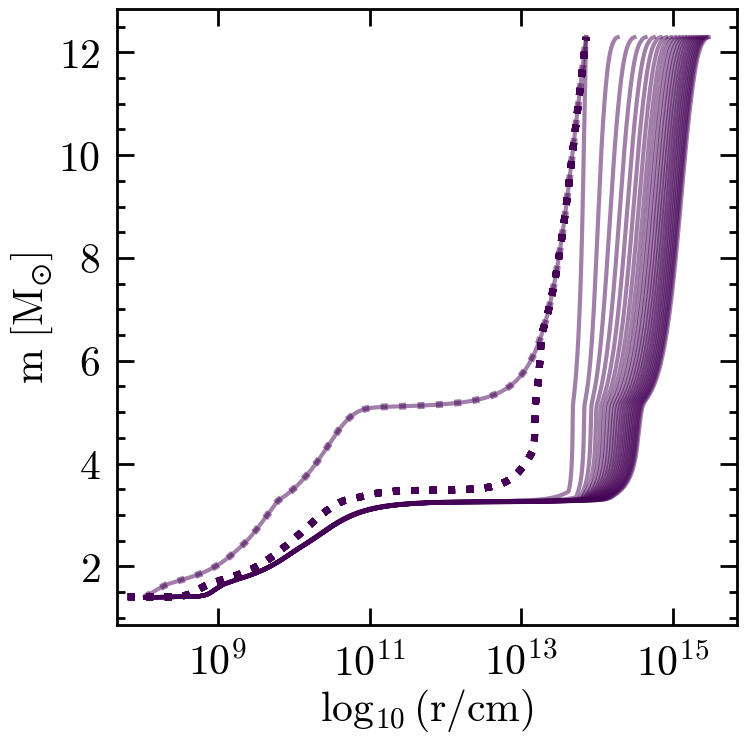

In [6]:
# mass vs time
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])


# get times 
# vel_data = SNEC_output_parser(new_baseline)
# keys = np.array(list(vel_data.keys()))
# vel_times = keys * u.s

for i, t in enumerate(vel_times[::200]):
    # if (i%2 == 0): continue
    plot_mass_radius(t, new_baseline_mass, ls='-', c=colors[i], ax=ax, lw=3, alpha=0.5, zorder=0)
    plot_mass_radius(t, bomb_negative_mass, ls=':', c=colors[i], ax=ax, lw=5, alpha=0.5, zorder=0)
    # plot_mass_radius(t, bomb48_mass, ls='--', c=colors[i], ax=ax, lw=4, alpha=0.5, zorder=0)
    # plot_mass_radius(t, bomb0_mass, ls='-', c=colors[i], ax=ax, lw=3, alpha=0.5, zorder=0)
    # plot_mass_radius(t, fallback1_mass, ls='-', c=colors[i], ax=ax, zorder=2)
    

ax.set_xscale("log")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")
ax.set_ylabel(r"$m \ [M_{\odot}]$")

/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:370: RuntimeWarning: invalid value encountered in log10
  ax.axvline(np.log10(radius[i_min_m].value), 0, 1, zorder=0, ls='--', lw=1, c='k')
/home/mrenzo/Documents/Research/codes/SNEC-1.01/scripts/plot_aux.py:373: RuntimeWarning: invalid value encountered in log10
  ax.plot(np.log10(radius.value), vel, **kwargs)


Text(0, 0.5, '$v \\ [\\mathrm{km\\ s^{-1}}]$')

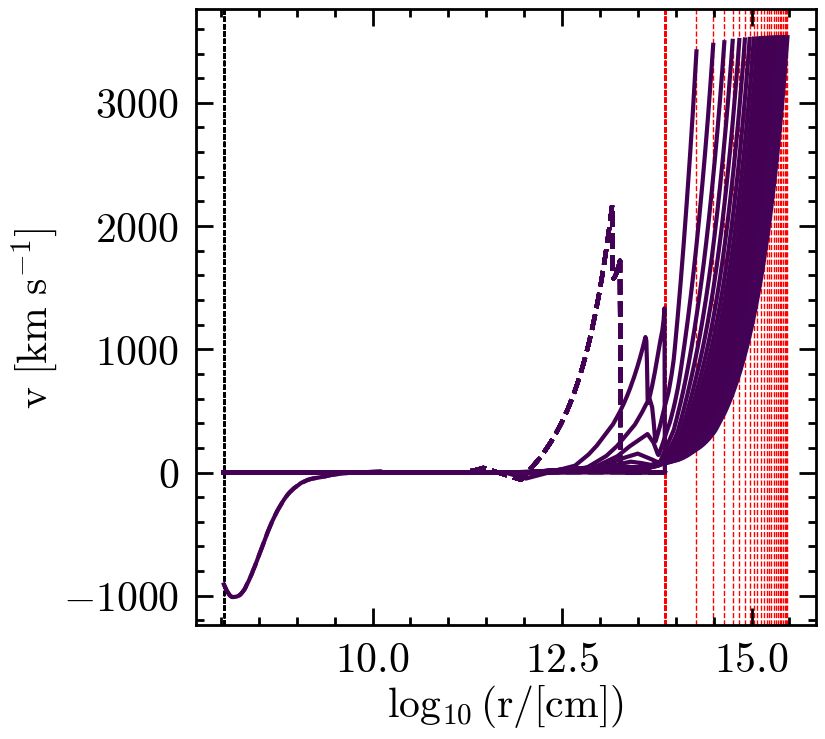

In [7]:
fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times[::200]):
    # if i%2 ==0: continue
    # alpha = max(min(1.0-(0.8 - 0.01*i), 1.0), 0.0)
    plot_v_radius_time(t, new_baseline_vel, new_baseline_mass, ax=ax, ls='-', lw=3, # label=f"{t.to(u.h):.1f}",
                       c=colors[i], # alpha=alpha
                       )
    plot_v_radius_time(t, bomb_negative_vel, bomb_negative_mass, ax=ax, label=f"{t.to(u.h):.1f}", zorder=1, ls='--',
                       # alpha=alpha,
                       c=colors[i]
                       )
    # plot_v_radius_time(t, bomb0_vel, bomb0_mass, ax=ax, label=f"{t.to(u.h):.1f}", zorder=1,
    #                    ls='--',# alpha=alpha,
    #                    c=colors[-1]
    #                    )
    

ax.set_xlabel(r'$\log_{10}(r/\mathrm{[cm]})$')
ax.set_ylabel(r'$v \ [\mathrm{km\ s^{-1}}]$')
# ax.legend(ncol=3, fontsize=20)
# ax.set_ylim(-10, 10)

In [17]:
# Mass vs time
mass_data = SNEC_output_parser(new_baseline_mass)
keys = np.array(list(mass_data.keys()))
mass_times = keys * u.s

for i, t in enumerate(mass_times):
    mass = mass_data[keys[i]][:, 1] * u.g
    print(t.to(u.days), min(mass).to(u.Msun), max(mass).to(u.Msun),mass(1).to(u.Msun), np.sum(mass).to(u.Msun))

NameError: name 'mass_times' is not defined

/tmp/ipykernel_1255757/1378338945.py:14: RuntimeWarning: divide by zero encountered in log10
  ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$m \\ [M_{\\odot}]$')

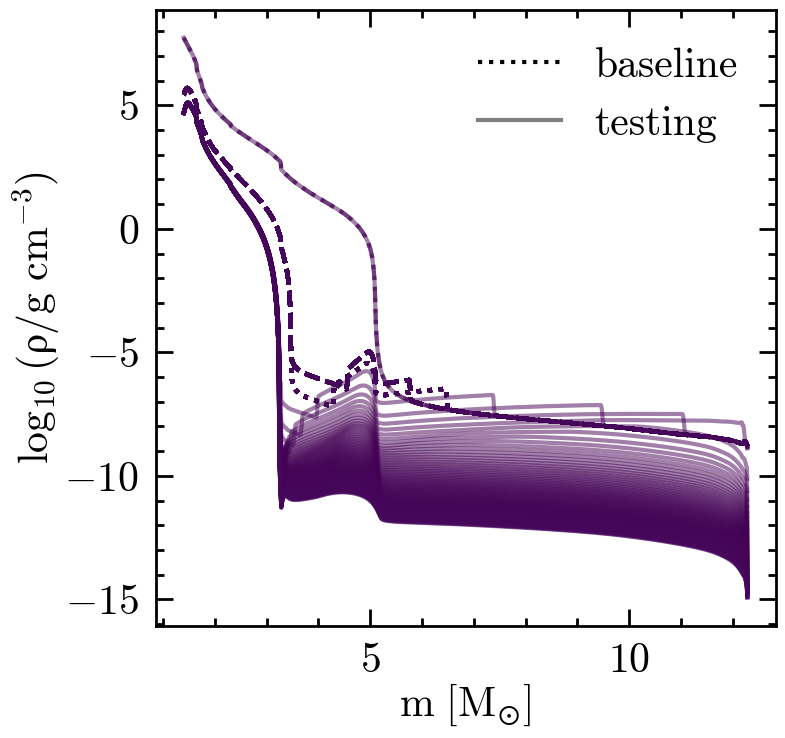

In [8]:
# density profiles?
def plot_rho_pfile(t, rho_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    ax.plot(mass.to(u.Msun), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])


for i, t in enumerate(vel_times[::50]):
    # print(i)
    plot_rho_pfile(t, new_baseline_rho, ax=ax, # label=f'{t}',
                   c=colors[i], lw=3, alpha=0.5)
    plot_rho_pfile(t, bomb0_rho, ax=ax, ls='--', alpha=0.5, c=colors[i])
    plot_rho_pfile(t, bomb_negative_rho, ax=ax, ls=':', alpha=0.5, c=colors[i])


ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=3, c='k', alpha=0.5, label="testing") # r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$m \ [M_{\odot}]$")

/tmp/ipykernel_1211201/3394954984.py:16: RuntimeWarning: divide by zero encountered in log10
  ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)


Text(0.5, 0, '$\\log_{10}(r/\\mathrm{cm})$')

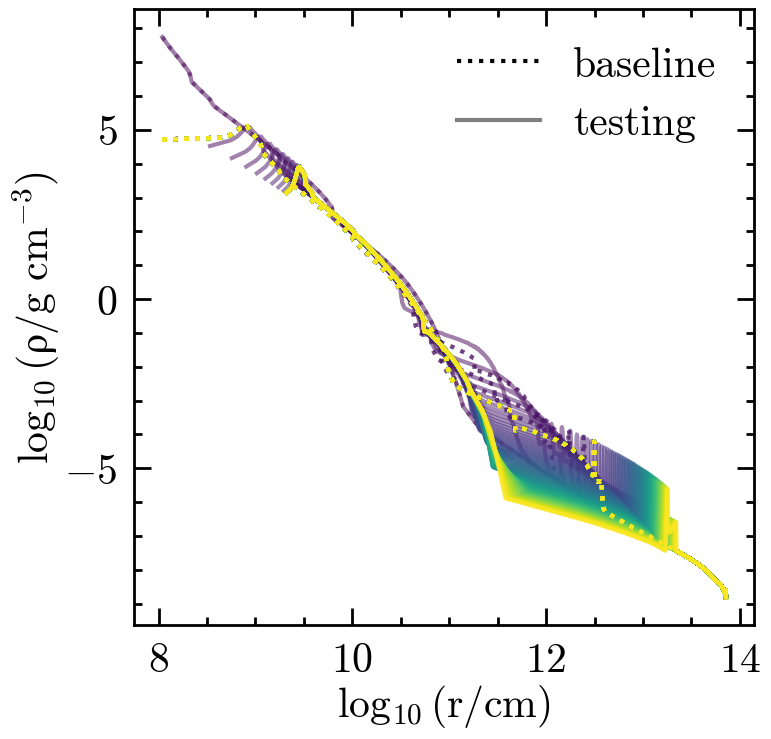

In [34]:
# Density vs. Radius
def plot_rho_r_pfile(t, rho_out, mass_out, ax=None, **kwargs):
    data = SNEC_output_parser(rho_out)
    keys = np.array(list(data.keys()))
    times = keys * u.s
    try:
        units = times.unit
    except AttributeError:
        times *= u.s
    index_time_of_interest = np.argmin(np.absolute(times-t))
    key_of_interest = keys[index_time_of_interest]
    rho = data[key_of_interest][:, 1] * u.g/u.cm**3
    mass = data[key_of_interest][:, 0] * u.g
    mass_data = SNEC_output_parser(mass_out)
    radius = mass_data[key_of_interest][:, 0] * u.cm
    ax.plot(np.log10(radius.to(u.cm).value), np.log10(rho.value), **kwargs)



fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

for i, t in enumerate(vel_times):
    # print(i)
    plot_rho_r_pfile(t, fallback1_rho, fallback1_mass, ax=ax, # label=f'{t}',
                     c=colors[i], lw=3, alpha=0.5)
    plot_rho_r_pfile(t, baseline_rho, baseline_mass,  ax=ax, ls=':', alpha=0.5, c=colors[i])


ax.plot(np.nan, np.nan, ls=":", c='k', label="baseline")
ax.plot(np.nan, np.nan, lw=3, c='k', alpha=0.5, label="testing") # r"$E_{\rm final}=0$")
ax.legend()
ax.set_ylabel(r"$\log_{10}(\rho/\mathrm{g\ cm^{-3}})$")
ax.set_xlabel(r"$\log_{10}(r/\mathrm{cm})$")


/tmp/ipykernel_1255757/2024610176.py:12: RuntimeWarning: divide by zero encountered in log10
  ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


Text(0, 0.5, '$\\log_{10}(L/\\mathrm{erg\\ s^{-1}})$')

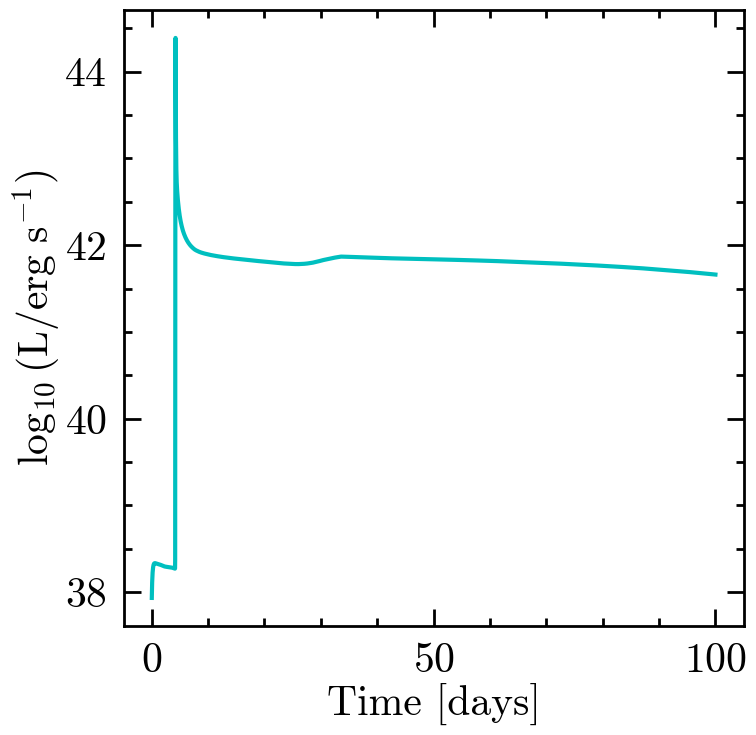

In [15]:
# light curve?
def plot_LC(folder, ax=None, **kwargs):
    obs_lum = folder+'lum_observed.dat'
    src = np.genfromtxt(obs_lum)
    t = src[:, 0] * u.s
    L = src[:,1] * u.erg/u.s
    if not ax:
        fig = plt.figure()
        gs = gridspec.GridSpec(150, 100)
        ax = fig.add_subplot(gs[:, :])
    #ax.scatter(t.to(u.d), np.log10(L.value), **kwargs)
    ax.plot(t.to(u.d), np.log10(L.value), **kwargs)


fig = plt.figure()
gs = gridspec.GridSpec(150, 100)
ax = fig.add_subplot(gs[:, :])

plot_LC(new_baseline, ax=ax, c='c', lw=3)
# plot_LC(bomb_negative, ax=ax, c='b', lw=3)
# plot_LC(bomb0, ax=ax, c='r', lw=5)
# plot_LC(bomb48, ax=ax, c='g', lw=7)
# plot_LC(fallback1, ax=ax, c='y', lw=9)


ax.set_xlabel(r"Time [days]")
ax.set_ylabel(r"$\log_{10}(L/\mathrm{erg\ s^{-1}})$")